<a href="https://colab.research.google.com/github/fmakkawi/Data-205/blob/main/Week11_EDA_Analysis_FarahMakkawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving income.csv to income.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving population.csv to population.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
income_df = pd.read_csv("income.csv")
population_df = pd.read_csv("population.csv")


In [7]:
print(income_df.columns)
print(population_df.columns)

Index(['GEO_ID', 'NAME', 'S1901_C01_001E', 'S1901_C01_001M', 'S1901_C01_002E',
       'S1901_C01_002M', 'S1901_C01_003E', 'S1901_C01_003M', 'S1901_C01_004E',
       'S1901_C01_004M',
       ...
       'S1901_C04_012M', 'S1901_C04_013E', 'S1901_C04_013M', 'S1901_C04_014E',
       'S1901_C04_014M', 'S1901_C04_015E', 'S1901_C04_015M', 'S1901_C04_016E',
       'S1901_C04_016M', 'Unnamed: 130'],
      dtype='object', length=131)
Index(['County', 'Total Population, 2018', 'Total Population, 2010',
       'Total Population, 2000', 'Population Change, 2000-2010',
       'Population Density per Square Mile', 'Median Age',
       'Per Capita Personal Income ($ Dollars)',
       'Median Household Income ($ Dollars)',
       'Total Personal Income ($ Thousands)'],
      dtype='object')


In [8]:
counties_income = ["Montgomery County, Maryland", "Prince George's County, Maryland"]
counties_pop = ["Montgomery County", "Prince George's County"]

income_filtered = income_df[income_df["NAME"].isin(counties_income)]
population_filtered = population_df[population_df["County"].isin(counties_pop)]


In [9]:
income_filtered = income_filtered[["NAME", "S1901_C01_012E"]]
income_filtered.columns = ["County", "Income"]

population_filtered = population_filtered[["County", "Total Population, 2018"]]
population_filtered.columns = ["County", "Population"]


In [10]:
print(income_filtered)
print(population_filtered)

                             County  Income
2       Montgomery County, Maryland  140837
3  Prince George's County, Maryland   99180
                    County Population
15       Montgomery County    1052567
16  Prince George's County     909308


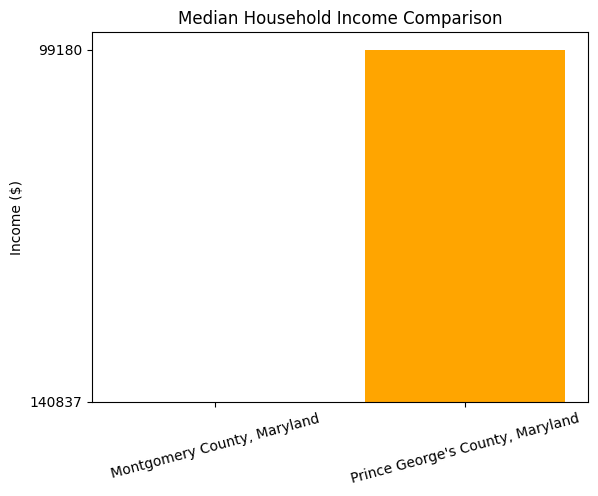

In [11]:
plt.figure()
plt.bar(income_filtered["County"], income_filtered["Income"], color=["blue", "orange"])
plt.title("Median Household Income Comparison")
plt.ylabel("Income ($)")
plt.xticks(rotation=15)
plt.show()

In [13]:
population_filtered["Population"] = population_filtered["Population"].astype(str).str.replace(",", "").astype(float)

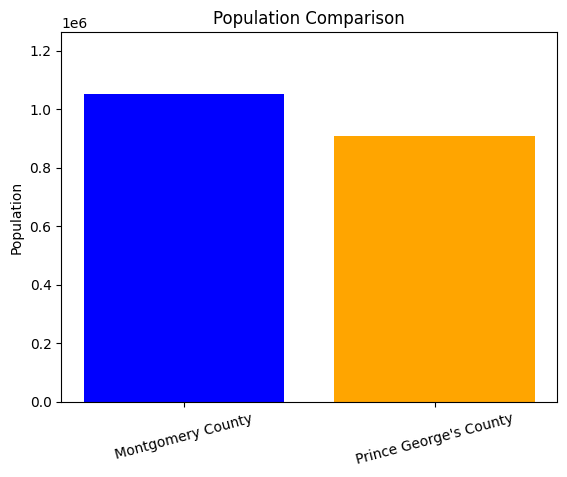

In [14]:
plt.figure()
plt.bar(population_filtered["County"], population_filtered["Population"], color=["blue", "orange"])
plt.title("Population Comparison")
plt.ylabel("Population")
plt.xticks(rotation=15)
plt.ylim(0, max(population_filtered["Population"]) * 1.2)
plt.show()

In [19]:
print(income_filtered["County"])
print(population_filtered["County"])

2         Montgomery County, Maryland
3    Prince George's County, Maryland
Name: County, dtype: object
15         Montgomery County
16    Prince George's County
Name: County, dtype: object


In [20]:
income_filtered["County"] = income_filtered["County"].str.strip()
population_filtered["County"] = population_filtered["County"].str.strip()

In [21]:
income_filtered["County"] = income_filtered["County"].replace({
    "Montgomery County, Maryland": "Montgomery County",
    "Prince George's County, Maryland": "Prince George's County"
})

population_filtered["County"] = population_filtered["County"].replace({
    "Montgomery County, Maryland": "Montgomery County",
    "Prince George's County, Maryland": "Prince George's County"
})

In [22]:
merged = pd.merge(income_filtered, population_filtered, on="County")
merged

,County,Income,Population
0,Montgomery County,140837,1052567.0
1,Prince George's County,99180,909308.0


In [23]:
merged["Income"] = merged["Income"].astype(str).str.replace(",", "", regex=False).astype(float)
merged["Population"] = merged["Population"].astype(str).str.replace(",", "", regex=False).astype(float)

merged["Income_per_Person"] = merged["Income"] / merged["Population"]
merged

,County,Income,Population,Income_per_Person
0,Montgomery County,140837.0,1052567.0,0.133803
1,Prince George's County,99180.0,909308.0,0.109072


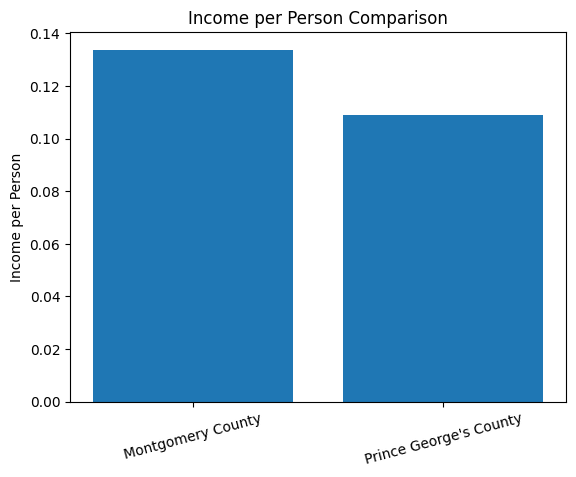

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(merged["County"], merged["Income_per_Person"])
plt.title("Income per Person Comparison")
plt.ylabel("Income per Person")
plt.xticks(rotation=15)
plt.show()

This extended analysis compares income per person between Montgomery County and Prince George’s County. After combining the datasets, the results show that Montgomery County has a higher income per person, indicating stronger economic conditions even when population size is considered.
